                                                  Stacking (FNN + XGBoost)

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\PIYUSH\Downloads\StarGalaxyQuaser1_TwinkleKashyap.csv")

In [4]:
import os
import random
import numpy as np
import tensorflow as tf

random.seed(42)


np.random.seed(42)


tf.random.set_seed(42)


os.environ['PYTHONHASHSEED'] = '42'

In [5]:

df.drop('objid', axis=1, inplace=True)

# Color features
df['u-g'] = df['u'] - df['g']
df['g-r'] = df['g'] - df['r']
df['r-i'] = df['r'] - df['i']
df['i-z'] = df['i'] - df['z']

# Data Cleaning
df = df[(df['u-g'] > -5) & (df['u-g'] < 5) &
        (df['g-r'] > -5) & (df['g-r'] < 5)]

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

In [7]:
X = df.drop('class', axis=1).values
y = df['class'].values

In [8]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, Y_train, test_size=0.2, random_state=42
)

X_tr_scaled, X_val_scaled, _, _ = train_test_split(
    X_train_scaled, Y_train, test_size=0.2, random_state=42
)

In [11]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss'
)

xgb.fit(X_tr, y_tr)

xgb_val_probs = xgb.predict_proba(X_val)
xgb_test_probs = xgb.predict_proba(X_test)

In [12]:
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_tr_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

C:\Users\PIYUSH\anaconda3\envs\astro_physics\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_tr)
weights = compute_class_weight('balanced', classes=classes, y=y_tr)
class_weights = dict(zip(classes, weights))

In [14]:
model.fit(
    X_tr_scaled, y_tr,
    epochs=50,
    batch_size=64,
    validation_data=(X_val_scaled, y_val),
    class_weight=class_weights,
    verbose=1
)

Epoch 1/50
866/866 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9394 - loss: 0.1908 - val_accuracy: 0.9732 - val_loss: 0.1127
Epoch 2/50
866/866 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9789 - loss: 0.0890 - val_accuracy: 0.9761 - val_loss: 0.0907
Epoch 3/50
866/866 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9830 - loss: 0.0745 - val_accuracy: 0.9788 - val_loss: 0.0835
Epoch 4/50
866/866 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9844 - loss: 0.0687 - val_accuracy: 0.9804 - val_loss: 0.0789
Epoch 5/50
866/866 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9858 - loss: 0.0646 - val_accuracy: 0.9809 - val_loss: 0.0784
Epoch 6/50
866/866 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9865 - loss: 0.0623 - val_accuracy: 0.9823 - val_loss: 0.0757
Epoch 7/50
866/866 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9870 - loss: 0.0598 - val_accuracy: 0.9830 - val_loss: 0.0738
Epoch 8/50
866/866 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9873 - loss: 0.0601 - val_accuracy: 0.

In [15]:
fnn_val_probs = model.predict(X_val_scaled)
fnn_test_probs = model.predict(X_test_scaled)

433/433 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step
928/928 ━━━━━━━━━━━━━━━━━━━━ 1s 742us/step


In [16]:
meta_X_val = np.hstack([xgb_val_probs, fnn_val_probs])
meta_X_test = np.hstack([xgb_test_probs, fnn_test_probs])

In [17]:
meta_model = LogisticRegression(max_iter=1000)
meta_model.fit(meta_X_val, y_val)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [18]:
final_pred = meta_model.predict(meta_X_test)

In [19]:
print("Stacking Accuracy:", accuracy_score(Y_test, final_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, final_pred))

print("\nClassification Report:")
print(classification_report(Y_test, final_pred))

Stacking Accuracy: 0.9935968725777643

Confusion Matrix:
[[17501    60    17]
 [  109  2657     0]
 [    4     0  9325]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     17578
           1       0.98      0.96      0.97      2766
           2       1.00      1.00      1.00      9329

    accuracy                           0.99     29673
   macro avg       0.99      0.99      0.99     29673
weighted avg       0.99      0.99      0.99     29673



                                                       K fold Stacking

In [20]:
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

n_classes = 3

# OOF predictions
oof_xgb = np.zeros((X_train.shape[0], n_classes))
oof_fnn = np.zeros((X_train.shape[0], n_classes))

# Test predictions (averaged)
test_xgb = np.zeros((X_test.shape[0], n_classes))
test_fnn = np.zeros((X_test.shape[0], n_classes))

In [21]:
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):

    print(f"\n Fold {fold+1}")

    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = Y_train[train_idx], Y_train[val_idx]

    X_tr_scaled, X_val_scaled = X_train_scaled[train_idx], X_train_scaled[val_idx]

    #XGBOOST 
    xgb = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        objective='multi:softprob',
        num_class=3,
        eval_metric='mlogloss'
    )

    xgb.fit(X_tr, y_tr)

    oof_xgb[val_idx] = xgb.predict_proba(X_val)
    test_xgb += xgb.predict_proba(X_test) / 5

    #  FNN 
    model = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(X_tr_scaled.shape[1],)),
        layers.Dense(64, activation='relu'),
        layers.Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Class weights
    classes = np.unique(y_tr)
    weights = compute_class_weight('balanced', classes=classes, y=y_tr)
    class_weights = dict(zip(classes, weights))

    model.fit(
        X_tr_scaled, y_tr,
        epochs=50,
        batch_size=64,
        verbose=0,
        class_weight=class_weights
    )

    oof_fnn[val_idx] = model.predict(X_val_scaled)
    test_fnn += model.predict(X_test_scaled) / 5


 Fold 1


C:\Users\PIYUSH\anaconda3\envs\astro_physics\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


433/433 ━━━━━━━━━━━━━━━━━━━━ 0s 820us/step
928/928 ━━━━━━━━━━━━━━━━━━━━ 1s 750us/step

 Fold 2


C:\Users\PIYUSH\anaconda3\envs\astro_physics\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


433/433 ━━━━━━━━━━━━━━━━━━━━ 0s 811us/step
928/928 ━━━━━━━━━━━━━━━━━━━━ 1s 732us/step

 Fold 3


C:\Users\PIYUSH\anaconda3\envs\astro_physics\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


433/433 ━━━━━━━━━━━━━━━━━━━━ 0s 841us/step
928/928 ━━━━━━━━━━━━━━━━━━━━ 1s 776us/step

 Fold 4


C:\Users\PIYUSH\anaconda3\envs\astro_physics\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


433/433 ━━━━━━━━━━━━━━━━━━━━ 0s 962us/step
928/928 ━━━━━━━━━━━━━━━━━━━━ 1s 782us/step

 Fold 5


C:\Users\PIYUSH\anaconda3\envs\astro_physics\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


433/433 ━━━━━━━━━━━━━━━━━━━━ 0s 841us/step
928/928 ━━━━━━━━━━━━━━━━━━━━ 1s 766us/step


In [22]:
meta_X_train = np.hstack([oof_xgb, oof_fnn])
meta_X_test = np.hstack([test_xgb, test_fnn])

In [23]:
meta_model = LogisticRegression(max_iter=1000)
meta_model.fit(meta_X_train, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [24]:
final_pred = meta_model.predict(meta_X_test)

In [25]:
print("K-Fold Stacking Accuracy:", accuracy_score(Y_test, final_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, final_pred))

print("\nClassification Report:")
print(classification_report(Y_test, final_pred))

K-Fold Stacking Accuracy: 0.9939001786135544

Confusion Matrix:
[[17509    48    21]
 [  108  2658     0]
 [    4     0  9325]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     17578
           1       0.98      0.96      0.97      2766
           2       1.00      1.00      1.00      9329

    accuracy                           0.99     29673
   macro avg       0.99      0.99      0.99     29673
weighted avg       0.99      0.99      0.99     29673



In [26]:
def plot_conf_matrix(y_true, final_pred , title):
    cm = confusion_matrix(y_true, final_pred )
    
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',linewidths=0.5, linecolor='black')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

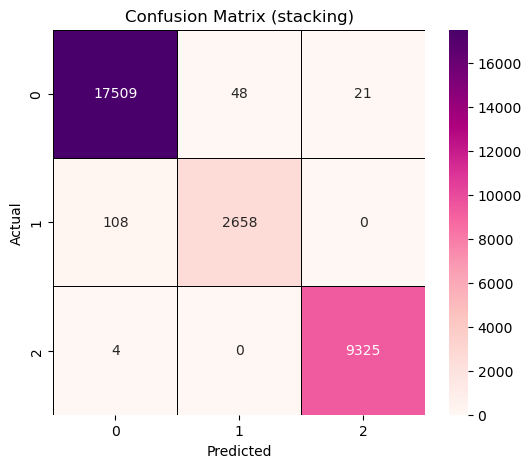

In [27]:
plot_conf_matrix(Y_test,final_pred , "Confusion Matrix (stacking)")

In [28]:
from sklearn.metrics import accuracy_score

# XGB only
pred_xgb = np.argmax(test_xgb, axis=1)
print("XGB Accuracy:", accuracy_score(Y_test, pred_xgb))

# FNN only
pred_fnn = np.argmax(test_fnn, axis=1)
print("FNN Accuracy:", accuracy_score(Y_test, pred_fnn))

# Stacking
pred_stack = final_pred
print("Stacking Accuracy:", accuracy_score(Y_test, final_pred))

XGB Accuracy: 0.9939001786135544
FNN Accuracy: 0.9909682202675834
Stacking Accuracy: 0.9939001786135544


In [29]:
acc_xgb = accuracy_score(Y_test, pred_xgb)
acc_fnn = accuracy_score(Y_test, pred_fnn)
acc_stack = accuracy_score(Y_test, pred_stack)


In [30]:
pred_xgb = np.argmax(test_xgb, axis=1)
pred_fnn = np.argmax(test_fnn, axis=1)

agree = (pred_xgb == pred_fnn)
disagree = (pred_xgb != pred_fnn)

print("Agreement %:", agree.mean())

# Accuracy when models agree
acc_agree = (final_pred[agree] == Y_test[agree]).mean()

# Accuracy when models disagree
acc_disagree = (final_pred[disagree] == Y_test[disagree]).mean()

print("Accuracy (agree):", acc_agree)
print("Accuracy (disagree):", acc_disagree)

Agreement %: 0.9942371853199878
Accuracy (agree): 0.9952884550199986
Accuracy (disagree): 0.7543859649122807


In [31]:
probs = meta_model.predict_proba(meta_X_test)
confidence = probs.max(axis=1)
high_conf = (confidence > 0.9).sum()
print("High confidence samples:", high_conf)

High confidence samples: 29515
